# Projet IPO — Notebook fusionné H1, H2, H3, H4



---

# Bloc H1


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
from statsmodels.stats.proportion import proportions_ztest

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

SEED = 42
ALPHA = 0.05
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C", "2022-2023": "#D7191C"}

IMG_DIR = Path("images")
IMG_DIR.mkdir(parents=True, exist_ok=True)


def _safe_filename(title):
    safe = re.sub(r"[\\/*?:\"<>|]", "", title).strip()
    return (safe.replace(" ", "_") or "figure")


def save_figure(title, fig=None, ext="png", dpi=300):
    fig = fig or plt.gcf()
    filename = f"{_safe_filename(title)}.{ext}"
    fig.savefig(IMG_DIR / filename, bbox_inches="tight", dpi=dpi)


print("Imports OK")


def load_data(path):
    """Charge un fichier CSV ou Excel."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {path}\n"
            "Remplace DATA_PATH au début du notebook par le vrai fichier CSV/XLSX."
        )
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    return pd.read_excel(path)


def require_columns(df, columns):
    """Vérifie que les colonnes nécessaires existent."""
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes : {missing}")


def add_cohort(df, year_col="year", high_label="2022-2024"):
    """Ajoute la cohorte 2019-2021 vs 2022-2024."""
    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    df = df[df[year_col].between(2019, 2024)].copy()
    df["cohort"] = np.where(df[year_col].between(2019, 2021), "2019-2021", high_label)
    return df


def apply_size_filter(df):
    """Applique les filtres méthodologiques minimaux du livrable 2."""
    df = df.copy()
    size_col = "Size_Million" if "Size_Million" in df.columns else ("ipo_size_m" if "ipo_size_m" in df.columns else None)
    if size_col is not None:
        df[size_col] = pd.to_numeric(df[size_col], errors="coerce")
        df = df[(df[size_col].isna()) | (df[size_col] >= 50)].copy()
    if "OfferPrice" in df.columns:
        df["OfferPrice"] = pd.to_numeric(df["OfferPrice"], errors="coerce")
        df = df[(df["OfferPrice"].isna()) | (df["OfferPrice"] > 5)].copy()
    return df


def bootstrap_ci(x, stat_fn=np.mean, n_boot=5000, alpha=0.05, seed=42):
    """Intervalle de confiance bootstrap percentile."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    gen = np.random.default_rng(seed)
    idx = gen.integers(0, len(x), size=(n_boot, len(x)))
    try:
        boot = stat_fn(x[idx], axis=1)
    except TypeError:
        boot = np.array([stat_fn(sample) for sample in x[idx]])
    return stat_fn(x), np.quantile(boot, alpha / 2), np.quantile(boot, 1 - alpha / 2)


def clean_h1(df):
    require_columns(df, ["year", "revenue_ltm", "profitable"])
    df = add_cohort(df)
    df = apply_size_filter(df)
    df["revenue_ltm"] = pd.to_numeric(df["revenue_ltm"], errors="coerce")

    src = df["profitable"]
    if pd.api.types.is_bool_dtype(src):
        df["profitable_bin"] = src.astype(float)
    elif pd.api.types.is_numeric_dtype(src):
        df["profitable_bin"] = (pd.to_numeric(src, errors="coerce") > 0).astype(float)
    else:
        txt = src.astype(str).str.strip().str.lower()
        yes = {"1", "true", "yes", "y", "oui", "rentable", "profitable", "positive"}
        no = {"0", "false", "no", "n", "non", "unprofitable", "negative"}
        df["profitable_bin"] = np.where(txt.isin(yes), 1.0, np.where(txt.isin(no), 0.0, np.nan))
    return df


def make_summary_h1(df):
    rows = []
    for cohort in ["2019-2021", "2022-2024"]:
        sub = df[df["cohort"] == cohort]
        rev = sub["revenue_ltm"].dropna()
        prof = sub["profitable_bin"].dropna()
        rows.append({
            "Cohorte": cohort,
            "N IPO": len(sub),
            "N CA": len(rev),
            "CA médian LTM (M$)": rev.median(),
            "CA Q1 (M$)": rev.quantile(0.25),
            "CA Q3 (M$)": rev.quantile(0.75),
            "N rentabilité": len(prof),
            "Part rentable": prof.mean(),
        })
    return pd.DataFrame(rows)


def _cohort_handles():
    return [
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor=COLORS["2019-2021"], markeredgecolor="none", label="2019-2021"),
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor=COLORS["2022-2024"], markeredgecolor="none", label="2022-2024"),
    ]


def plot_h1_revenue(df):
    revenue = df.dropna(subset=["revenue_ltm"])
    revenue = revenue[revenue["revenue_ltm"] > 0]
    cohort_order = ["2019-2021", "2022-2024"]
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=revenue,
        x="cohort",
        y="revenue_ltm",
        order=cohort_order,
        palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
        ax=ax,
    )
    ax.set_yscale("log")
    for idx, cohort in enumerate(cohort_order):
        values = revenue.loc[revenue["cohort"] == cohort, "revenue_ltm"].dropna()
        if len(values):
            median_value = values.median()
            ax.text(idx, median_value, f"{median_value:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    title = "H1.1 - Chiffre d'affaires LTM par cohorte"
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("CA LTM (M$, échelle log)")
    ax.legend(handles=_cohort_handles(), title="Cohorte", loc="upper right")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()


def plot_h1_profitability(df):
    prop = (
        df.dropna(subset=["profitable_bin"])
        .groupby("cohort")["profitable_bin"]
        .mean()
        .reindex(["2019-2021", "2022-2024"])
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(prop.index, prop.values * 100, color=[COLORS["2019-2021"], COLORS["2022-2024"]])
    for bar, value in zip(bars, prop.values):
        ax.text(bar.get_x() + bar.get_width() / 2, value * 100 + 1, f"{value:.1%}", ha="center")
    title = "H1.2 - Part d'entreprises rentables à l'IPO"
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Part rentable (%)")
    ax.set_ylim(0, max(70, np.nanmax(prop.values * 100) + 10))
    ax.legend(handles=_cohort_handles(), title="Cohorte", loc="upper right")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()


def plot_h1(df):
    plot_h1_revenue(df)
    plot_h1_profitability(df)


def run_tests_h1(df):
    rev_low = df.loc[df["cohort"] == "2019-2021", "revenue_ltm"].dropna()
    rev_high = df.loc[df["cohort"] == "2022-2024", "revenue_ltm"].dropna()
    prof_low = df.loc[df["cohort"] == "2019-2021", "profitable_bin"].dropna()
    prof_high = df.loc[df["cohort"] == "2022-2024", "profitable_bin"].dropna()

    _u_stat, p_mw = stats.mannwhitneyu(rev_high, rev_low, alternative="greater")
    _z_stat, p_z = proportions_ztest(
        [int(prof_high.sum()), int(prof_low.sum())],
        [len(prof_high), len(prof_low)],
        alternative="larger",
    )

    med_low, med_low_lo, med_low_hi = bootstrap_ci(rev_low, np.median, seed=SEED)
    med_high, med_high_lo, med_high_hi = bootstrap_ci(rev_high, np.median, seed=SEED + 1)

    return pd.DataFrame({
        "Indicateur": ["CA médian", "IC95 CA médian", "Part rentable", "Test Mann-Whitney CA", "Z-test proportion rentable"],
        "2019-2021": [med_low, f"[{med_low_lo:.2f} ; {med_low_hi:.2f}]", prof_low.mean(), "", ""],
        "2022-2024": [med_high, f"[{med_high_lo:.2f} ; {med_high_hi:.2f}]", prof_high.mean(), "", ""],
        "Valeur test": ["", "", "", p_mw, p_z],
    })


Imports OK


In [3]:
DATA_PATH = "data/dataset.xlsx"
FRED_PATH = "data/fred_annual.xlsx"

## 5. Chargement et préparation des données

On charge le fichier, on garde le périmètre du livrable 2 et on crée les cohortes.

Effectifs par cohorte :


,N
cohort,
2019-2021,271
2022-2024,136


,Cohorte,N IPO,N CA,CA médian LTM (M$),CA Q1 (M$),CA Q3 (M$),N rentabilité,Part rentable
0,2019-2021,271,228,134.25,18.02,406.90,271,22.51%
1,2022-2024,136,136,18.87,0.00,731.51,136,58.82%


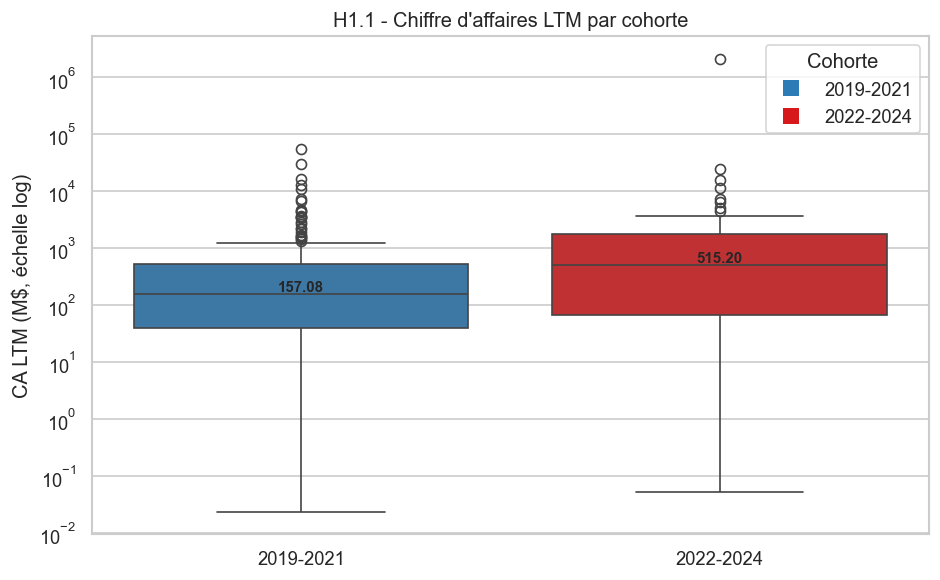

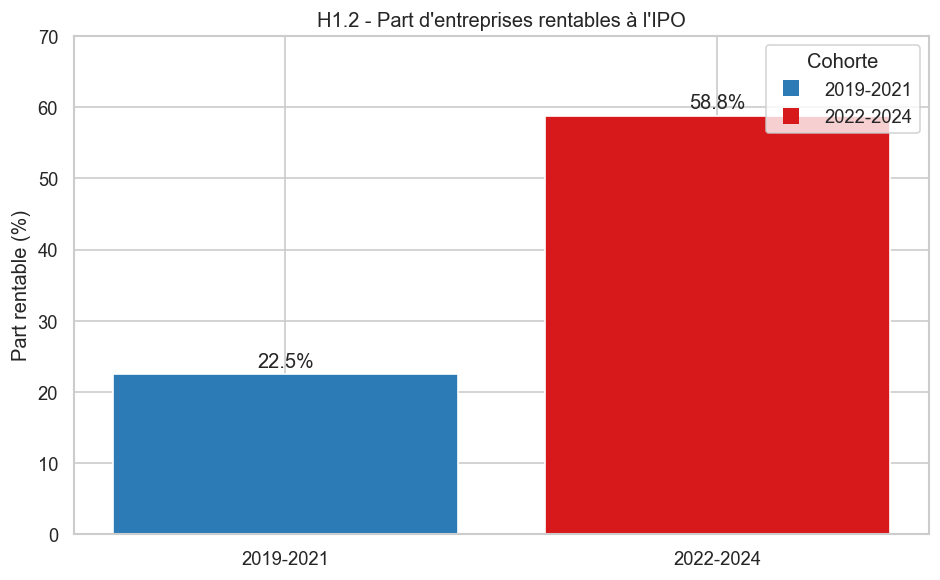

,Indicateur,2019-2021,2022-2024,Valeur test
0,CA médian,134.245705,18.872,
1,IC95 CA médian,[82.47 ; 167.07],[2.85 ; 136.77],
2,Part rentable,0.225092,0.588235,
3,Test Mann-Whitney CA,,,0.995882
4,Z-test proportion rentable,,,0.0


Lecture : H1 est soutenue si le CA médian et la part rentable sont plus élevés en 2022-2024, avec p-value < 5%.


In [4]:
df = load_data(DATA_PATH)
df = clean_h1(df)

print("Effectifs par cohorte :")
display(df["cohort"].value_counts().reindex(["2019-2021", "2022-2024"]).to_frame("N"))

summary = make_summary_h1(df)
display(summary.style.format({
    "CA médian LTM (M$)": "{:.2f}",
    "CA Q1 (M$)": "{:.2f}",
    "CA Q3 (M$)": "{:.2f}",
    "Part rentable": "{:.2%}",
}))

plot_h1(df)

test_h1 = run_tests_h1(df)
display(test_h1)

print("Lecture : H1 est soutenue si le CA médian et la part rentable sont plus élevés en 2022-2024, avec p-value < 5%.")


## Conclusion courte pour l’oral

Pour H1, on compare le profil des entreprises introduites en bourse entre 2019-2021 et 2022-2024.  
Les variables centrales sont le chiffre d'affaires LTM et la rentabilité nette.  
La méthode repose sur une comparaison descriptive, un boxplot en échelle log, un barplot de rentabilité, un test de Mann-Whitney et un test de proportion.  
La limite principale est que les données de rentabilité et de revenu peuvent être incomplètes selon les IPO.

---

# Bloc H2


# H2 — Analyse simplifiée de l'underpricing

## 1. Objectif de l'hypothèse

On vérifie si le rendement du premier jour est plus faible en période de taux élevés.

## 2. Bibliothèques utilisées

On utilise uniquement des bibliothèques classiques : pandas, numpy, matplotlib, seaborn, scipy et statsmodels si nécessaire.

In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

SEED = 42
ALPHA = 0.05
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C", "2022-2023": "#D7191C"}

print("Imports OK")


Imports OK


## 3. Paramètres principaux

Remplace seulement les chemins ci-dessous par tes vrais fichiers.

In [6]:
DATA_PATH = "data/dataset.xlsx"
FRED_PATH = "data/fred_annual.xlsx"

## 4. Fonctions simples

Les fonctions suivantes gardent la logique visible : chargement, nettoyage, cohortes, tableaux, graphiques et tests.

In [7]:
import statsmodels.formula.api as smf

if "save_figure" not in globals():
    import re
    IMG_DIR = Path("images")
    IMG_DIR.mkdir(parents=True, exist_ok=True)

    def _safe_filename(title):
        safe = re.sub(r"[\\/*?:\"<>|]", "", title).strip()
        return (safe.replace(" ", "_") or "figure")

    def save_figure(title, fig=None, ext="png", dpi=300):
        fig = fig or plt.gcf()
        filename = f"{_safe_filename(title)}.{ext}"
        fig.savefig(IMG_DIR / filename, bbox_inches="tight", dpi=dpi)


def load_optional_fred(path):
    """Charge FRED si le fichier est disponible."""
    path = Path(path)
    if path.exists():
        return load_data(path)
    print("Fichier FRED non trouvé : le graphique annuel utilisera la colonne fed_rate du dataset si elle existe.")
    return None


def clean_h2(df):
    require_columns(df, ["year", "underpricing"])
    df = add_cohort(df)
    df = apply_size_filter(df)

    df["underpricing_raw"] = pd.to_numeric(df["underpricing"], errors="coerce")
    if {"close_px", "OfferPrice"}.issubset(df.columns):
        df["close_px"] = pd.to_numeric(df["close_px"], errors="coerce")
        df["OfferPrice"] = pd.to_numeric(df["OfferPrice"], errors="coerce")
        df["underpricing_recalc"] = (df["close_px"] - df["OfferPrice"]) / df["OfferPrice"]
        df["underpricing"] = df["underpricing_recalc"]
    else:
        df["underpricing"] = df["underpricing_raw"]

    df["underpricing_suspect"] = (~df["underpricing"].between(-0.95, 2.00)) | df["underpricing"].isna()
    n_suspect = int(df["underpricing_suspect"].sum())
    if n_suspect:
        print(f"H2 diagnostic : {n_suspect} observations exclues car underpricing impossible/suspect (< -95% ou > 200%).")
        display(
            df.loc[df["underpricing_suspect"], [col for col in ["ticker", "year", "OfferPrice", "open_px", "close_px", "underpricing_raw", "underpricing"] if col in df.columns]]
            .sort_values("underpricing", ascending=False)
            .head(15)
        )
    df = df[~df["underpricing_suspect"]].copy()

    if "fed_rate" in df.columns:
        df["fed_rate"] = pd.to_numeric(df["fed_rate"], errors="coerce")
    size_col = "Size_Million" if "Size_Million" in df.columns else ("ipo_size_m" if "ipo_size_m" in df.columns else None)
    if size_col is not None:
        size_values = pd.to_numeric(df[size_col], errors="coerce")
        df["log_size"] = np.log(size_values.where(size_values > 0))
    return df.dropna(subset=["underpricing", "cohort"]).copy()


def validate_h2_sample(df):
    checks = []
    size_col = "Size_Million" if "Size_Million" in df.columns else ("ipo_size_m" if "ipo_size_m" in df.columns else None)
    if size_col is not None:
        checks.append([f"{size_col} >= 50 M$", df[size_col].min(), (df[size_col] >= 50).mean()])
    if "OfferPrice" in df.columns:
        checks.append(["OfferPrice > 5 $", df["OfferPrice"].min(), (df["OfferPrice"] > 5).mean()])
    if "underpricing_suspect" in df.columns:
        checks.append(["Underpricing conservé dans [-95%; 200%]", df["underpricing"].min(), (~df["underpricing_suspect"]).mean()])
    if not checks:
        return pd.DataFrame({"Message": ["Critères quantitatifs non vérifiables ici."]})
    return pd.DataFrame(checks, columns=["Critère", "Minimum observé", "% conforme"])


def make_summary_h2(df):
    return (
        df.groupby("cohort")["underpricing"]
        .agg(N="count", Moyenne="mean", Médiane="median", Ecart_type="std", Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75))
        .reindex(["2019-2021", "2022-2024"])
        .reset_index()
    )


def _h2_handles():
    return [
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor=COLORS["2019-2021"], markeredgecolor="none", label="2019-2021"),
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor=COLORS["2022-2024"], markeredgecolor="none", label="2022-2024"),
    ]


def plot_h2_distributions(df):
    for cohort in ["2019-2021", "2022-2024"]:
        values = df.loc[df["cohort"] == cohort, "underpricing"].dropna()
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.histplot(values, bins=35, kde=True, color=COLORS[cohort], alpha=0.65, ax=ax)
        mean_value = values.mean()
        median_value = values.median()
        ax.axvline(mean_value, color="black", linestyle="--", linewidth=1, label=f"Moyenne = {mean_value:.2%}")
        ax.axvline(median_value, color="gray", linestyle=":", linewidth=1.2, label=f"Médiane = {median_value:.2%}")
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.4)
        ax.set_xlim(-0.5, 0.8)
        title = f"H2.1 - Distribution de l'underpricing ({cohort})"
        ax.set_title(title)
        ax.set_xlabel("Underpricing J0")
        ax.set_ylabel("Nombre d'IPO")
        ax.legend(title="Repères", loc="upper right")
        plt.tight_layout()
        save_figure(title, fig)
        plt.show()


def plot_h2_boxplot(df):
    fig, ax = plt.subplots(figsize=(8, 5))
    cohort_order = ["2019-2021", "2022-2024"]
    sns.boxplot(
        data=df,
        x="cohort",
        y="underpricing",
        order=cohort_order,
        palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
        ax=ax,
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    for idx, cohort in enumerate(cohort_order):
        values = df.loc[df["cohort"] == cohort, "underpricing"].dropna()
        if len(values):
            median_value = values.median()
            ax.text(idx, median_value, f"{median_value:.2%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    title = "H2.2 - Comparaison de l'underpricing entre cohortes"
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Underpricing au premier jour")
    ax.legend(handles=_h2_handles(), title="Cohorte", loc="upper right")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()


def plot_h2_by_year(df):
    yearly = df.groupby("year").agg(
        underpricing_moyen=("underpricing", "mean"),
        underpricing_median=("underpricing", "median"),
        n=("underpricing", "count"),
    ).reset_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = [COLORS["2019-2021"] if y <= 2021 else COLORS["2022-2024"] for y in yearly["year"]]
    bars = ax.bar(yearly["year"], yearly["underpricing_moyen"], color=colors, alpha=0.8)
    for bar, value in zip(bars, yearly["underpricing_moyen"]):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.2%}", ha="center", va="bottom", fontsize=9)
    ax.plot(yearly["year"], yearly["underpricing_median"], color="orange", marker="D", linestyle="--", label="Médiane")
    ax.axvline(2021.5, color="purple", linestyle=":", alpha=0.7, label="Frontière 2021")
    ax.axhline(0, color="black", linewidth=0.6)
    title = "H2.3 - Underpricing moyen par année"
    ax.set_title(title)
    ax.set_xlabel("Année")
    ax.set_ylabel("Underpricing")
    ax.legend(title="Repères", loc="upper right")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()

    if "fed_rate" in df.columns:
        fed_yearly = df.groupby("year")["fed_rate"].mean().reset_index()
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.plot(fed_yearly["year"], fed_yearly["fed_rate"], color="#2C3E50", marker="o", linewidth=2, label="Taux Fed")
        for x, y in zip(fed_yearly["year"], fed_yearly["fed_rate"]):
            ax.text(x, y, f"{y:.2f}", ha="center", va="bottom", fontsize=9)
        ax.axvline(2021.5, color="purple", linestyle=":", alpha=0.7)
        title = "H2.4 - Taux Fed moyen par année"
        ax.set_title(title)
        ax.set_xlabel("Année")
        ax.set_ylabel("Taux Fed (%)")
        ax.legend(title="Série", loc="upper right")
        plt.tight_layout()
        save_figure(title, fig)
        plt.show()


def run_tests_h2(df):
    low = df.loc[df["cohort"] == "2019-2021", "underpricing"].dropna()
    high = df.loc[df["cohort"] == "2022-2024", "underpricing"].dropna()
    u_stat, p_mw = stats.mannwhitneyu(low, high, alternative="greater")
    t_stat, p_welch = stats.ttest_ind(low, high, equal_var=False, nan_policy="omit")
    robust = np.nan
    low_no_2021 = df.loc[(df["cohort"] == "2019-2021") & (df["year"] != 2021), "underpricing"].dropna()
    if len(low_no_2021) and len(high):
        _, robust = stats.mannwhitneyu(low_no_2021, high, alternative="greater")
    return pd.DataFrame({
        "Test": ["Mann-Whitney unilatéral", "Welch bilatéral", "Mann-Whitney sans 2021"],
        "Hypothèse": ["2019-2021 > 2022-2024", "moyennes différentes", "robustesse sans euphorie 2021"],
        "Statistique": [u_stat, t_stat, np.nan],
        "p-value": [p_mw, p_welch, robust],
        "Significatif 5%": [p_mw < ALPHA, p_welch < ALPHA, robust < ALPHA if np.isfinite(robust) else False],
    })


def run_ols_h2(df):
    vars_needed = ["underpricing", "fed_rate", "log_size", "pe_backed", "sector"]
    if not all(v in df.columns for v in vars_needed):
        print("OLS non exécutée : colonnes nécessaires absentes :", [v for v in vars_needed if v not in df.columns])
        return None
    work = df[vars_needed].dropna().copy()
    if len(work) < 10:
        print("OLS non exécutée : trop peu d'observations après suppression des NaN.")
        return None
    model = smf.ols("underpricing ~ fed_rate + log_size + pe_backed + C(sector)", data=work).fit(cov_type="HC3")
    table = model.summary2().tables[1].loc[[i for i in ["Intercept", "fed_rate", "log_size", "pe_backed"] if i in model.params.index]]
    display(table)

    coef = table["Coef."]
    ci_low = table["[0.025"]
    ci_high = table["0.975]"]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(coef.index, coef.values, xerr=[coef - ci_low, ci_high - coef])
    ax.axvline(0, color="black", linewidth=1)
    title = "H2.5 - Coefficients OLS principaux avec IC 95% robustes HC3"
    ax.set_title(title)
    ax.set_xlabel("Coefficient")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()
    return model


## 5. Chargement et préparation des données

On charge le fichier, on garde le périmètre du livrable 2 et on crée les cohortes.

H2 diagnostic : 44 observations exclues car underpricing impossible/suspect (< -95% ou > 200%).


,ticker,year,OfferPrice,open_px,close_px,underpricing_raw,underpricing
5,DUO,2019,13.00,46800.000000,46800.000000,3599.000000,3599.000000
244,ARBK,2021,15.00,3242.159912,3618.000000,240.200000,240.200000
135,BCAB,2020,18.00,1527.500000,1551.000000,85.166667,85.166667
193,COOK,2021,18.00,1100.000000,1100.000000,60.111111,60.111111
57,YJ,2019,11.00,540.000000,566.000000,50.454545,50.454545
34,KRRO,2019,14.00,560.000000,685.000000,47.928571,47.928571
190,BIRD,2021,15.00,428.399994,577.799988,37.519999,37.519999
155,PYPD,2020,16.00,480.000000,570.000000,34.625000,34.625000
339,ICON,2024,18.75,681.280735,663.352295,34.378789,34.378789
152,OM,2020,27.00,780.000000,910.200012,32.711112,32.711112


Vérification rapide de l'échantillon :


,Critère,Minimum observé,% conforme
0,Size_Million >= 50 M$,50.400000,1.0
1,OfferPrice > 5 $,5.500000,1.0
2,Underpricing conservé dans [-95%; 200%],-0.869767,1.0


Statistiques descriptives :


,cohort,N,Moyenne,Médiane,Ecart_type,Q1,Q3
0,2019-2021,231,27.66%,22.21%,41.94%,0.00%,48.03%
1,2022-2024,132,6.89%,0.56%,27.28%,-2.02%,14.29%


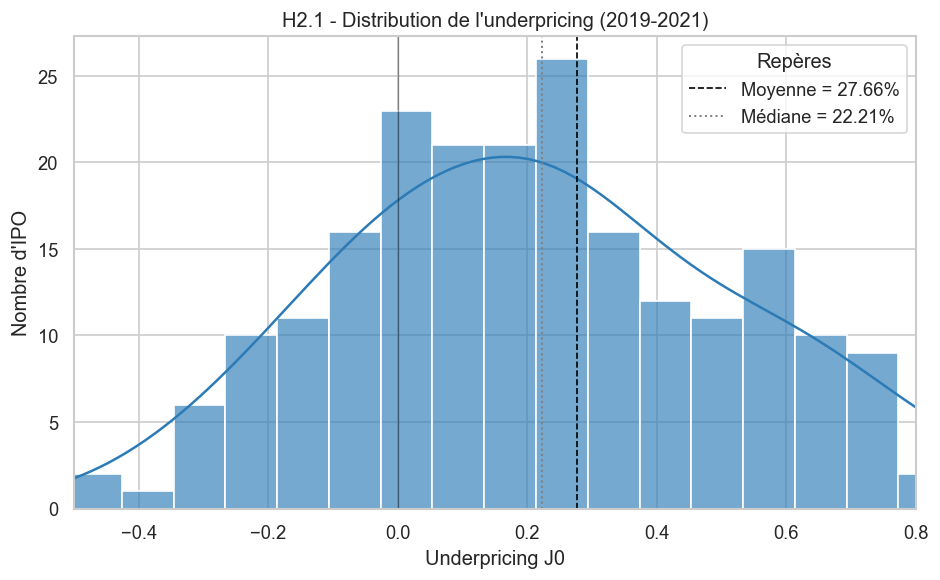

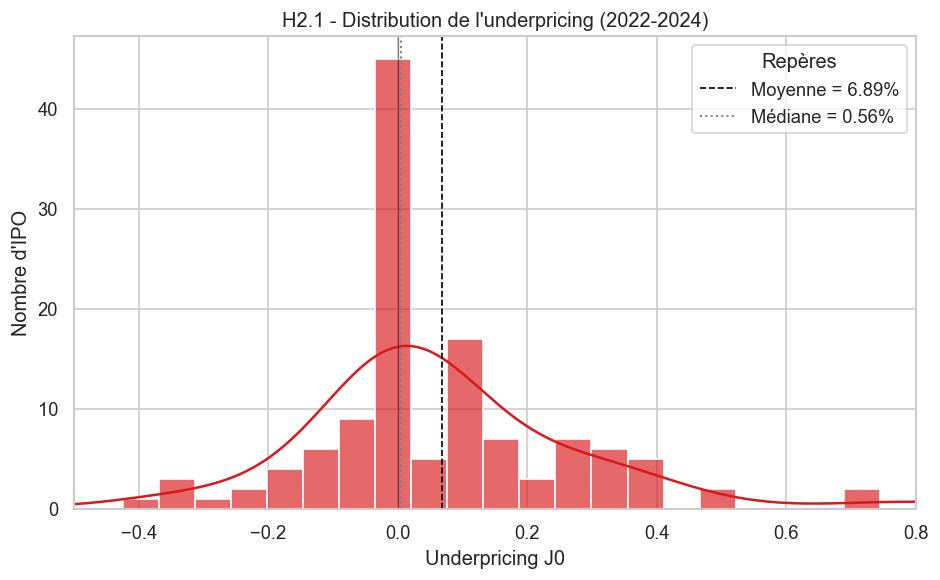

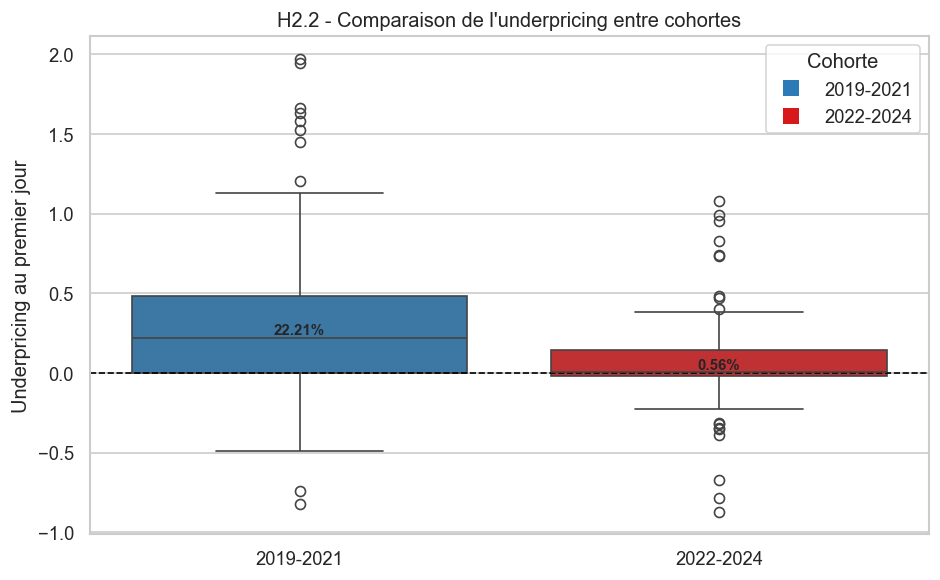

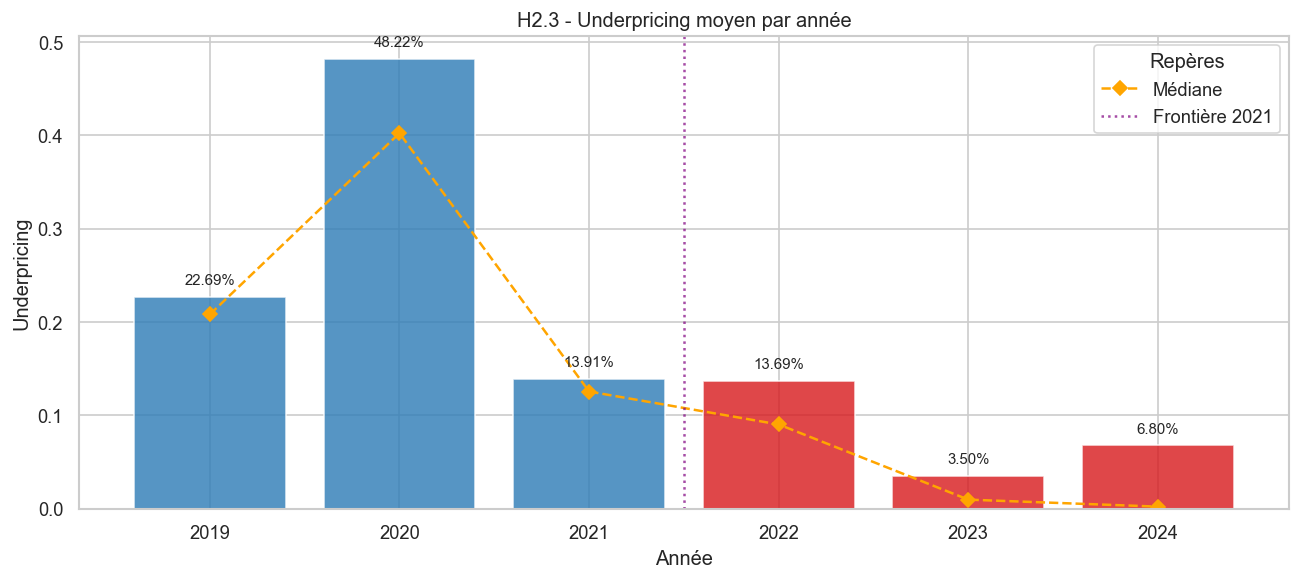

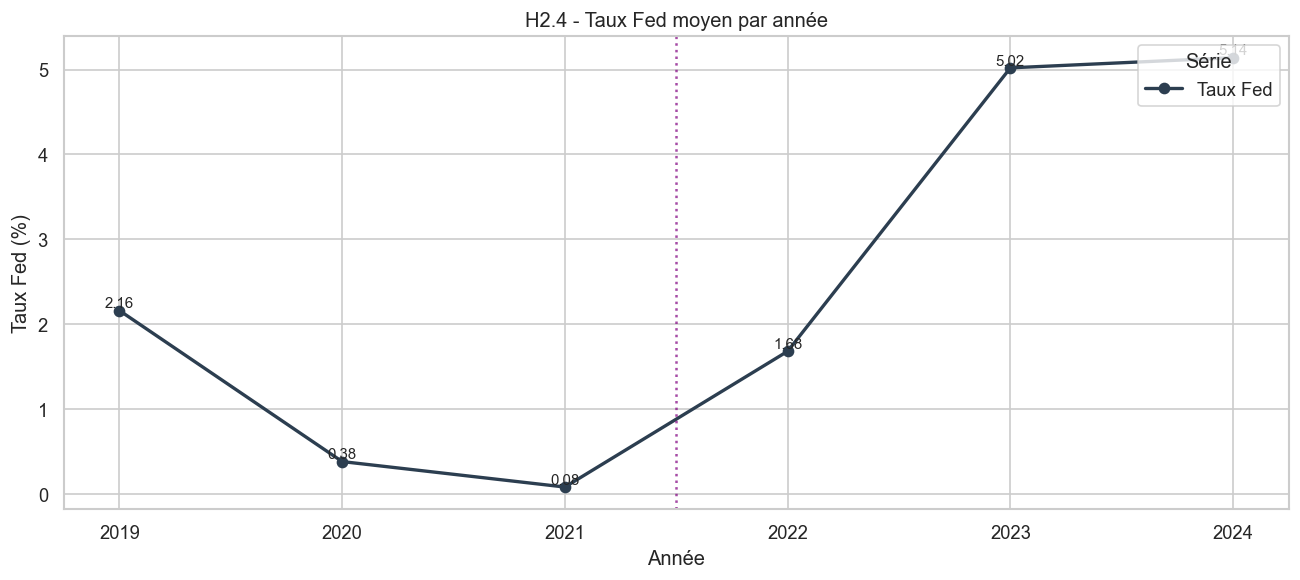

Tests statistiques principaux :


,Test,Hypothèse,Statistique,p-value,Significatif 5%
0,Mann-Whitney unilatéral,2019-2021 > 2022-2024,20338.0000,0.0000,True
1,Welch bilatéral,moyennes différentes,5.7070,0.0000,True
2,Mann-Whitney sans 2021,robustesse sans euphorie 2021,nan,0.0000,True


Régression OLS si les colonnes de contrôle existent :


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,0.056107,0.117946,0.475699,0.634289,-0.175063,0.287277
fed_rate,-0.031824,0.009219,-3.452090,0.000556,-0.049892,-0.013755
log_size,0.046935,0.019015,2.468273,0.013577,0.009666,0.084204
pe_backed,0.037954,0.045878,0.827272,0.408083,-0.051966,0.127873


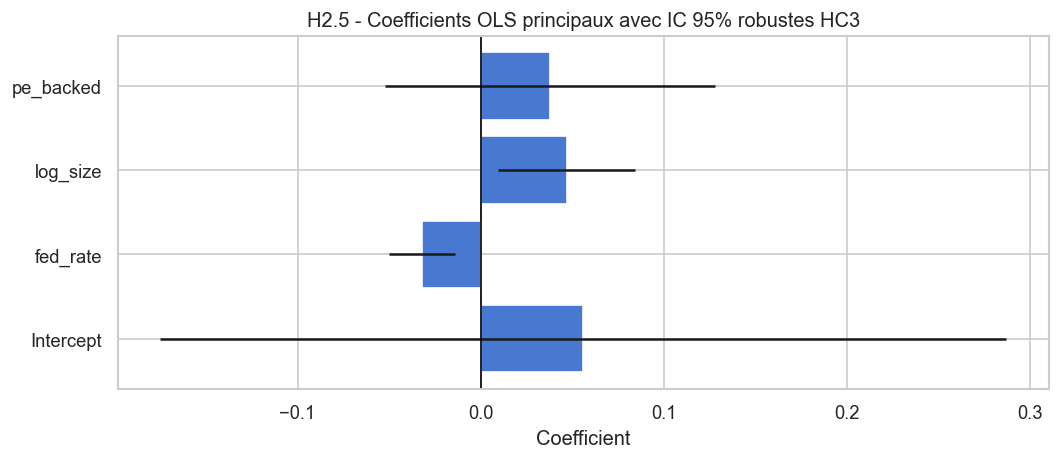

Lecture : H2 est soutenue si 2022-2024 présente un underpricing plus faible, confirmé par Mann-Whitney et par le signe négatif du coefficient fed_rate en OLS.


In [8]:
df = load_data(DATA_PATH)
fred = load_optional_fred(FRED_PATH)

df = clean_h2(df)

print("Vérification rapide de l'échantillon :")
display(validate_h2_sample(df))

print("Statistiques descriptives :")
summary = make_summary_h2(df)
display(summary.style.format({
    "Moyenne": "{:.2%}",
    "Médiane": "{:.2%}",
    "Ecart_type": "{:.2%}",
    "Q1": "{:.2%}",
    "Q3": "{:.2%}",
}))

plot_h2_distributions(df)
plot_h2_boxplot(df)
plot_h2_by_year(df)

print("Tests statistiques principaux :")
tests = run_tests_h2(df)
display(tests.style.format({"Statistique": "{:.4f}", "p-value": "{:.4f}"}))

print("Régression OLS si les colonnes de contrôle existent :")
ols_model = run_ols_h2(df)

print("Lecture : H2 est soutenue si 2022-2024 présente un underpricing plus faible, confirmé par Mann-Whitney et par le signe négatif du coefficient fed_rate en OLS.")


## Conclusion courte pour l’oral

Pour H2, on teste si l'underpricing est plus faible en 2022-2024 qu'en 2019-2021.  
La variable centrale est le rendement du premier jour.  
La méthode combine statistiques descriptives, histogrammes/KDE, boxplot, comparaison annuelle avec le taux Fed, Mann-Whitney, Welch, OLS et robustesse sans 2021.  
La limite principale est que le taux annuel ne sépare pas parfaitement l'effet macroéconomique des effets de cohorte, de secteur et d'euphorie de 2021.

---

# Bloc H3




# H3 — Analyse simplifiée de la performance à 30 jours

## 1. Objectif de l'hypothèse

On vérifie si les rendements à 30 jours sont plus stables en 2022-2024.

## 2. Bibliothèques utilisées

On utilise uniquement des bibliothèques classiques : pandas, numpy, matplotlib, seaborn, scipy et statsmodels si nécessaire.

In [9]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

SEED = 42
ALPHA = 0.05
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C", "2022-2023": "#D7191C"}

print("Imports OK")


Imports OK


## 3. Paramètres principaux

Remplace seulement les chemins ci-dessous par tes vrais fichiers.

In [10]:
DATA_PATH = "data/dataset.xlsx"
FRED_PATH = "data/fred_annual.xlsx"

## 4. Fonctions simples

Les fonctions suivantes gardent la logique visible : chargement, nettoyage, cohortes, tableaux, graphiques et tests.

In [11]:
if "save_figure" not in globals():
    import re
    IMG_DIR = Path("images")
    IMG_DIR.mkdir(parents=True, exist_ok=True)

    def _safe_filename(title):
        safe = re.sub(r"[\\/*?:\"<>|]", "", title).strip()
        return (safe.replace(" ", "_") or "figure")

    def save_figure(title, fig=None, ext="png", dpi=300):
        fig = fig or plt.gcf()
        filename = f"{_safe_filename(title)}.{ext}"
        fig.savefig(IMG_DIR / filename, bbox_inches="tight", dpi=dpi)


def clean_h3(df):
    require_columns(df, ["year", "ret_30d"])
    df = add_cohort(df)
    df = apply_size_filter(df)
    df["ret_30d"] = pd.to_numeric(df["ret_30d"], errors="coerce")
    return df.dropna(subset=["ret_30d"]).copy()


def make_summary_h3(df):
    summary = (
        df.assign(ret_30d_pct=df["ret_30d"] * 100)
        .groupby("cohort")["ret_30d_pct"]
        .agg(
            Ecart_type="std",
            Variance="var",
            IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
            Minimum="min",
            Maximum="max",
        )
        .reindex(["2019-2021", "2022-2024"])
        .reset_index()
    )
    return summary


def _cohort_handles():
    return [
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor=COLORS["2019-2021"], markeredgecolor="none", label="2019-2021"),
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor=COLORS["2022-2024"], markeredgecolor="none", label="2022-2024"),
    ]


def _annotate_bars(ax, bars, values, fmt="{:.2f}"):
    for bar, value in zip(bars, values):
        ax.annotate(
            fmt.format(value),
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 4),
            textcoords="offset points",
        )


def plot_h3_boxplot(df):
    plot_df = df.copy()
    plot_df["ret_30d_pct"] = plot_df["ret_30d"] * 100
    cohort_order = ["2019-2021", "2022-2024"]
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=plot_df,
        x="cohort",
        y="ret_30d_pct",
        order=cohort_order,
        palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
        ax=ax,
        width=0.5,
        fliersize=3,
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    for idx, cohort in enumerate(cohort_order):
        values = plot_df.loc[plot_df["cohort"] == cohort, "ret_30d_pct"].dropna()
        if len(values):
            median_value = values.median()
            ax.text(idx, median_value, f"{median_value:.2f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    title = "H3.1 - Boxplot des rendements à 30 jours"
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Rendement à 30 jours (%)")
    ax.legend(handles=_cohort_handles(), title="Cohorte", loc="upper right")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()


def plot_h3_metric(df, column, title, ylabel):
    summary = make_summary_h3(df)
    cohort_order = ["2019-2021", "2022-2024"]
    values = summary[column].to_numpy()
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(cohort_order, values, color=[COLORS[c] for c in cohort_order])
    _annotate_bars(ax, bars, values, fmt="{:.2f}")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.legend(handles=_cohort_handles(), title="Cohorte", loc="upper right")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()


def plot_h3(df):
    plot_h3_boxplot(df)
    plot_h3_metric(df, "Ecart_type", "H3.2 - Écart-type des rendements à 30 jours", "Écart-type en points de %")
    plot_h3_metric(df, "Variance", "H3.3 - Variance des rendements à 30 jours", "Variance en points de %")
    plot_h3_metric(df, "IQR", "H3.4 - Intervalle interquartile des rendements à 30 jours", "IQR en points de %")
    plot_h3_metric(df, "Minimum", "H3.5 - Minimum des rendements à 30 jours", "Minimum en points de %")
    plot_h3_metric(df, "Maximum", "H3.6 - Maximum des rendements à 30 jours", "Maximum en points de %")


## 5. Chargement et préparation des données

On charge le fichier, on garde le périmètre du livrable 2 et on crée les cohortes.

Diagnostic H3 : rendement à 30 jours maximum observé en 2022-2024 = 917.89%. Les observations avec ret_30d > 917.89% seront exclues pour éviter les valeurs extrêmes suspectes.
Statistiques descriptives :


,cohort,Ecart_type,Variance,IQR,Minimum,Maximum
0,2019-2021,30.90,954.89,29.60,-66.84,185.81
1,2022-2024,19.41,376.77,17.22,-64.64,65.91


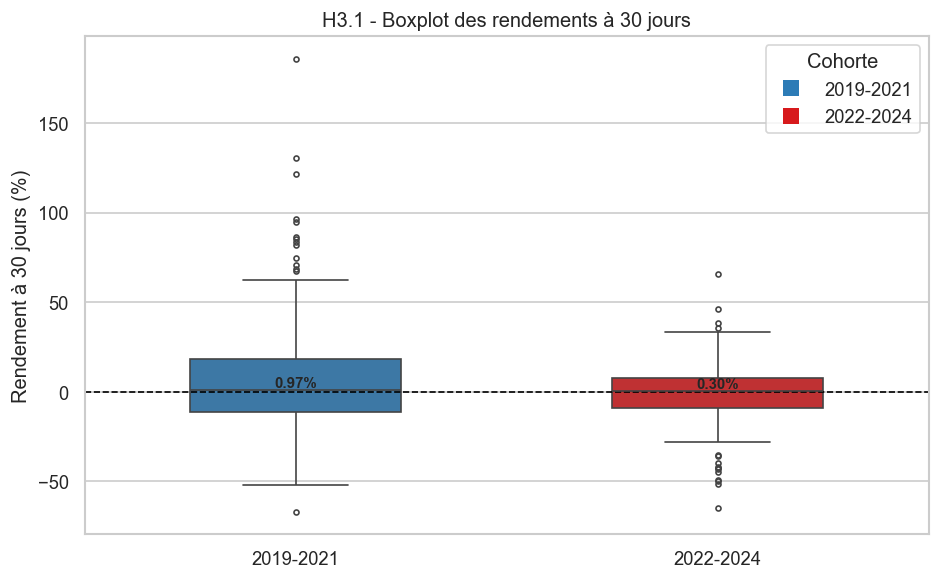

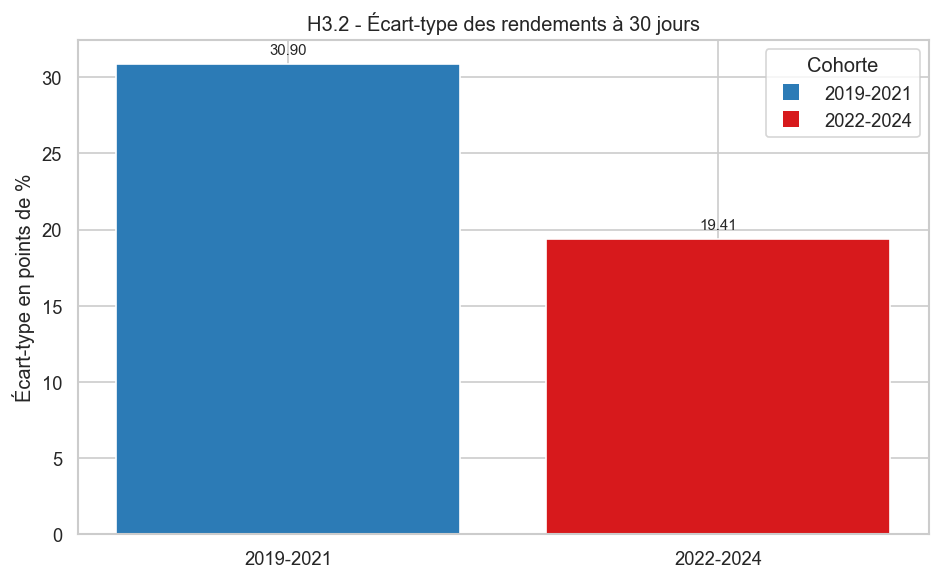

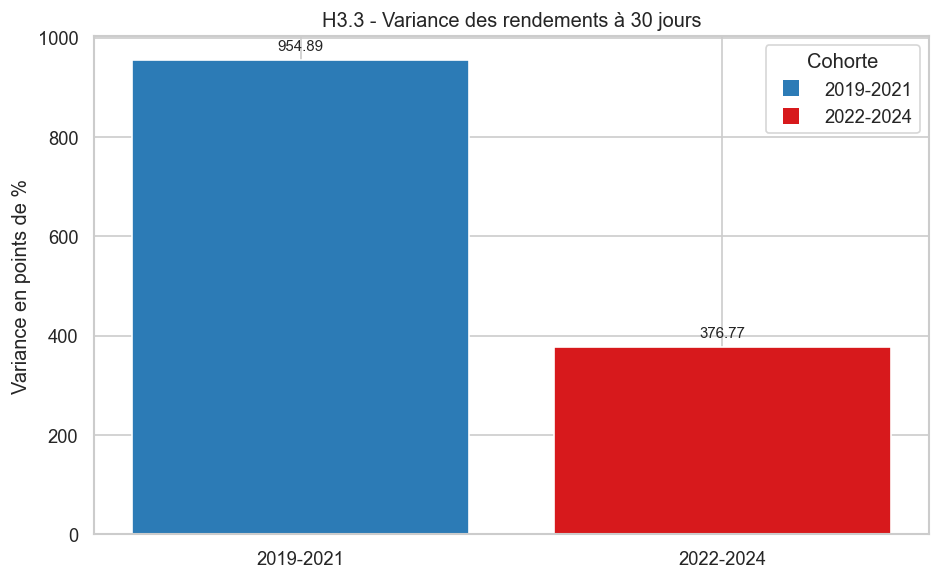

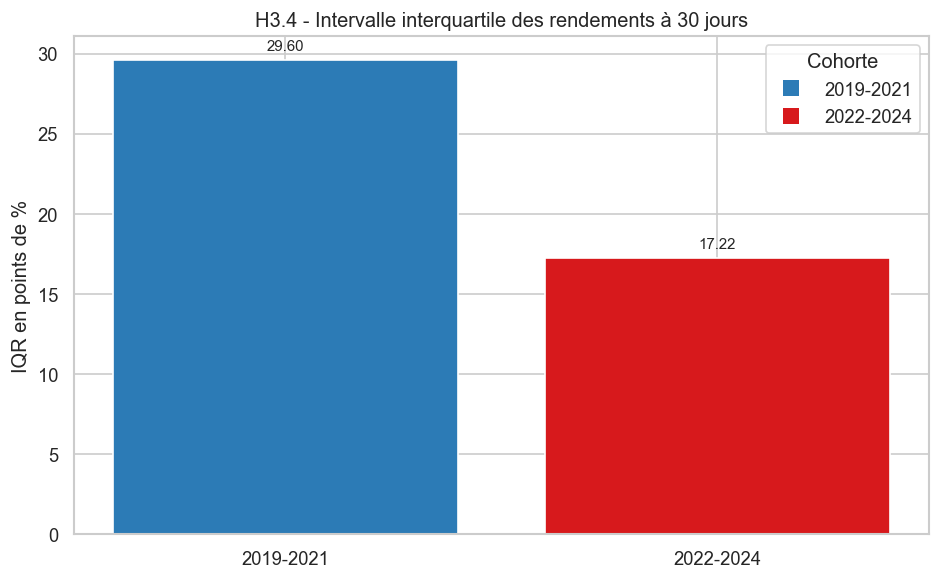

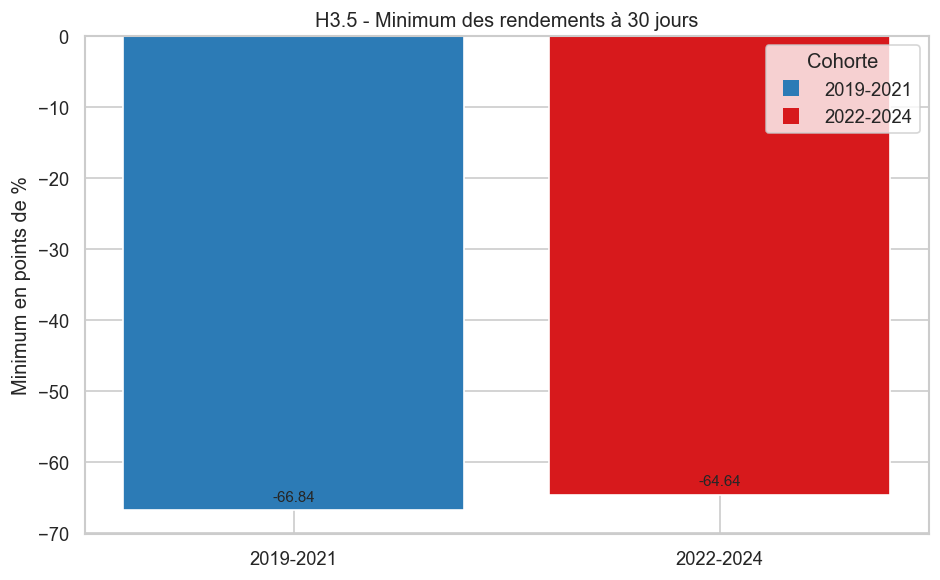

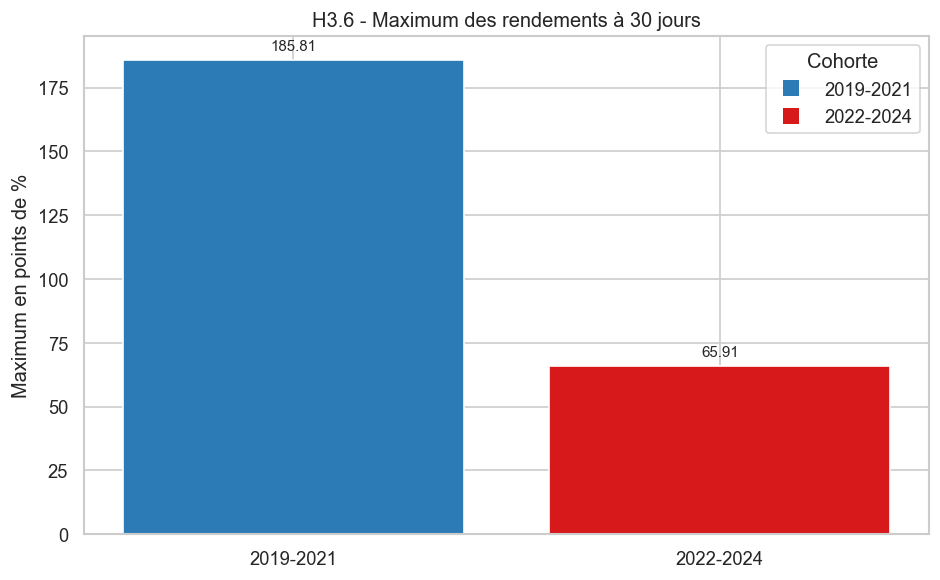

Lecture : H3 se lit via le boxplot et les statistiques de dispersion descriptives, sans test de Mann-Whitney.


In [27]:
df = load_data(DATA_PATH)
df = clean_h3(df)

max_ret_30d = df.loc[df["cohort"] == "2022-2024", "ret_30d"].max()
print(f"Diagnostic H3 : rendement à 30 jours maximum observé en 2022-2024 = {max_ret_30d:.2%}. Les observations avec ret_30d > {max_ret_30d:.2%} seront exclues pour éviter les valeurs extrêmes suspectes.")
df = df[df["ret_30d"] < max_ret_30d].copy()

print("Statistiques descriptives :")
summary = make_summary_h3(df)
display(summary.style.format({
    "Ecart_type": "{:.2f}",
    "Variance": "{:.2f}",
    "IQR": "{:.2f}",
    "Minimum": "{:.2f}",
    "Maximum": "{:.2f}",
}))

plot_h3(df)

print("Lecture : H3 se lit via le boxplot et les statistiques de dispersion descriptives, sans test de Mann-Whitney.")

df.to_csv("data/clean_h4.csv", index=False)

## Conclusion courte pour l’oral

Pour H3, on décrit la stabilité des rendements à 30 jours uniquement avec cinq analyses : boxplot, écart-type, variance, IQR, minimum et maximum.  
La variable centrale est `ret_30d`.  
La lecture attendue se fait sur la dispersion descriptive, sans test de Mann-Whitney.  
La limite principale est que la stabilité mesurée ici est une dispersion entre IPO, pas une volatilité quotidienne intra-titre.

---

# Bloc H4


# H4 — Analyse simplifiée de la performance à 12 mois

## 1. Objectif de l'hypothèse

On vérifie si la performance à 12 mois est meilleure pour les IPO récentes disposant d'un recul suffisant.

## 2. Bibliothèques utilisées

On utilise uniquement des bibliothèques classiques : pandas, numpy, matplotlib, seaborn, scipy et statsmodels si nécessaire.

In [13]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

SEED = 42
ALPHA = 0.05
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C", "2022-2023": "#D7191C"}

print("Imports OK")


Imports OK


## 3. Paramètres principaux

Remplace seulement les chemins ci-dessous par tes vrais fichiers.

In [14]:
DATA_PATH = "data/dataset.xlsx"
FRED_PATH = "data/fred_annual.xlsx"

## 4. Fonctions simples

Les fonctions suivantes gardent la logique visible : chargement, nettoyage, cohortes, tableaux, graphiques et tests.

In [15]:
if "save_figure" not in globals():
    import re
    IMG_DIR = Path("images")
    IMG_DIR.mkdir(parents=True, exist_ok=True)

    def _safe_filename(title):
        safe = re.sub(r"[\\/*?:\"<>|]", "", title).strip()
        return (safe.replace(" ", "_") or "figure")

    def save_figure(title, fig=None, ext="png", dpi=300):
        fig = fig or plt.gcf()
        filename = f"{_safe_filename(title)}.{ext}"
        fig.savefig(IMG_DIR / filename, bbox_inches="tight", dpi=dpi)


def clean_h4(df):
    require_columns(df, ["year", "ret_12m"])
    df = df.copy()
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df = df[df["year"].between(2019, 2024)].copy()
    df["cohort_h4"] = np.where(df["year"].between(2019, 2021), "2019-2021", "2022-2024")
    df = apply_size_filter(df)
    df["ret_12m"] = pd.to_numeric(df["ret_12m"], errors="coerce")
    return df.dropna(subset=["ret_12m"]).copy()


def make_summary_h4(df):
    return (
        df.groupby("cohort_h4")["ret_12m"]
        .agg(N="count", Moyenne="mean", Médiane="median", Ecart_type="std", Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75))
        .reindex(["2019-2021", "2022-2024"])
        .reset_index()
    )


def _cohort_handles():
    return [
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor=COLORS["2019-2021"], markeredgecolor="none", label="2019-2021"),
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor=COLORS["2022-2024"], markeredgecolor="none", label="2022-2024"),
    ]


def plot_h4_boxplot(df):
    fig, ax = plt.subplots(figsize=(8, 5))
    cohort_order = ["2019-2021", "2022-2024"]
    sns.boxplot(
        data=df,
        x="cohort_h4",
        y="ret_12m",
        order=cohort_order,
        palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
        ax=ax,
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    for idx, cohort in enumerate(cohort_order):
        values = df.loc[df["cohort_h4"] == cohort, "ret_12m"].dropna()
        if len(values):
            median_value = values.median()
            ax.text(idx, median_value, f"{median_value:.2%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    title = "H4.1 - Distribution des rendements à 12 mois"
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Rendement à 12 mois")
    ax.legend(handles=_cohort_handles(), title="Cohorte", loc="upper right")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()


def plot_h4_density(df):
    fig, ax = plt.subplots(figsize=(8, 5))
    if df["cohort_h4"].nunique() == 2:
        sns.kdeplot(
            data=df,
            x="ret_12m",
            hue="cohort_h4",
            hue_order=["2019-2021", "2022-2024"],
            fill=True,
            common_norm=False,
            palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
            alpha=0.25,
            ax=ax,
        )
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.legend(handles=_cohort_handles(), title="Cohorte", loc="upper right")
    else:
        ax.text(0.5, 0.5, "Données insuffisantes pour comparer les densités", ha="center", va="center")
        ax.axis("off")
    title = "H4.2 - Densité des rendements à 12 mois"
    ax.set_title(title)
    ax.set_xlabel("Rendement à 12 mois")
    ax.set_ylabel("Densité")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()


def plot_h4(df):
    plot_h4_boxplot(df)
    plot_h4_density(df)


def run_tests_h4(df):
    low = df.loc[df["cohort_h4"] == "2019-2021", "ret_12m"].dropna()
    high = df.loc[df["cohort_h4"] == "2022-2024", "ret_12m"].dropna()
    mean_low, mean_low_lo, mean_low_hi = bootstrap_ci(low, np.mean, seed=SEED)
    mean_high, mean_high_lo, mean_high_hi = bootstrap_ci(high, np.mean, seed=SEED + 1)
    med_low, med_low_lo, med_low_hi = bootstrap_ci(low, np.median, seed=SEED + 2)
    med_high, med_high_lo, med_high_hi = bootstrap_ci(high, np.median, seed=SEED + 3)
    _u_stat, p_mw = stats.mannwhitneyu(high, low, alternative="greater")
    _t_stat, p_welch_two = stats.ttest_ind(high, low, equal_var=False, nan_policy="omit")
    p_welch = p_welch_two / 2 if _t_stat > 0 else 1 - p_welch_two / 2
    return pd.DataFrame({
        "Indicateur": ["Moyenne", "IC95 moyenne", "Médiane", "IC95 médiane", "Mann-Whitney p-value", "Welch p-value"],
        "2019-2021": [mean_low, f"[{mean_low_lo:.4f} ; {mean_low_hi:.4f}]", med_low, f"[{med_low_lo:.4f} ; {med_low_hi:.4f}]", "", ""],
        "2022-2024": [mean_high, f"[{mean_high_lo:.4f} ; {mean_high_hi:.4f}]", med_high, f"[{med_high_lo:.4f} ; {med_high_hi:.4f}]", "", ""],
        "Valeur test": ["", "", "", "", p_mw, p_welch],
    })


## 5. Chargement et préparation des données

On charge le fichier, on garde le périmètre du livrable 2 et on crée les cohortes.

Effectifs utilisés pour H4 :


,N
cohort_h4,
2019-2021,271
2022-2024,136


,cohort_h4,N,Moyenne,Médiane,Ecart_type,Q1,Q3
0,2019-2021,271,-1.26%,-27.10%,95.28%,-58.18%,22.73%
1,2022-2024,136,1.82%,4.55%,58.69%,-41.57%,25.24%


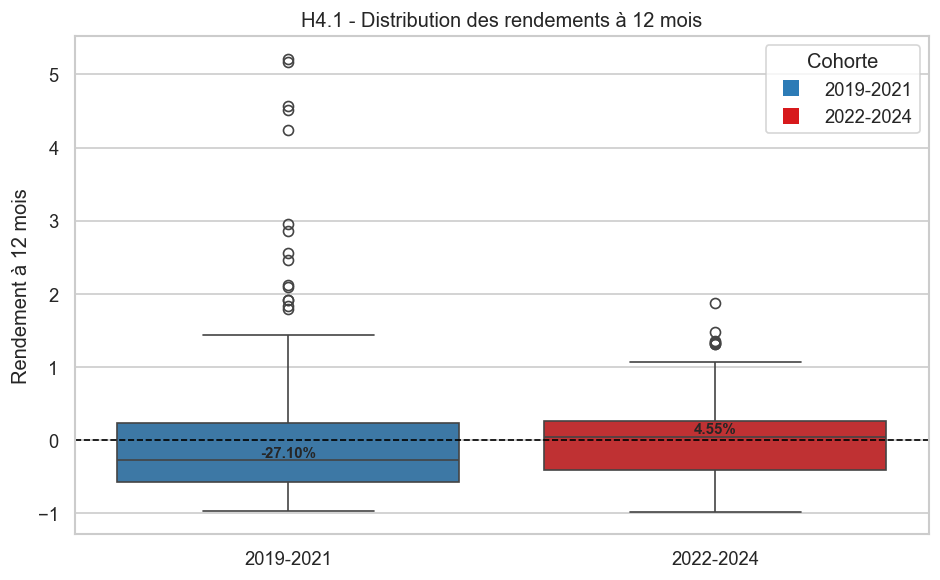

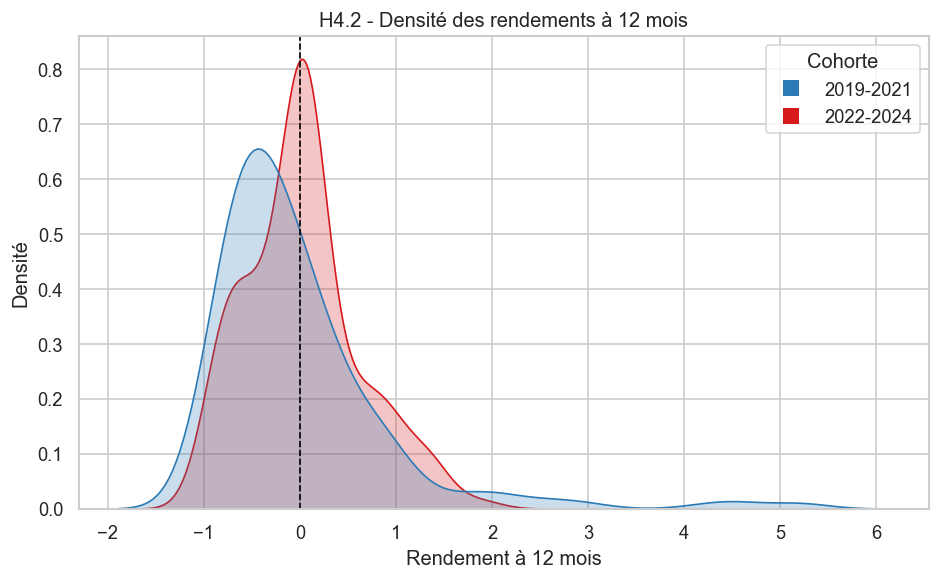

Tests et intervalles de confiance :


,Indicateur,2019-2021,2022-2024,Valeur test
0,Moyenne,-0.012588,0.018239,
1,IC95 moyenne,[-0.1207 ; 0.1097],[-0.0782 ; 0.1171],
2,Médiane,-0.271008,0.045468,
3,IC95 médiane,[-0.3401 ; -0.1750],[-0.0255 ; 0.0515],
4,Mann-Whitney p-value,,,0.004796
5,Welch p-value,,,0.34399


Lecture : H4 est soutenue si les rendements à 12 mois de 2022-2024 sont supérieurs et si Mann-Whitney est significatif.


In [16]:
df = load_data(DATA_PATH)
df = clean_h4(df)


print("Effectifs utilisés pour H4 :")
display(df["cohort_h4"].value_counts().reindex(["2019-2021", "2022-2024"]).to_frame("N"))

summary = make_summary_h4(df)
display(summary.style.format({
    "Moyenne": "{:.2%}",
    "Médiane": "{:.2%}",
    "Ecart_type": "{:.2%}",
    "Q1": "{:.2%}",
    "Q3": "{:.2%}",
}))

plot_h4(df)

print("Tests et intervalles de confiance :")
tests = run_tests_h4(df)
display(tests)

print("Lecture : H4 est soutenue si les rendements à 12 mois de 2022-2024 sont supérieurs et si Mann-Whitney est significatif.")

In [17]:
df.to_csv("clean_h4.csv", index=False)

## Conclusion courte pour l'oral

Pour H4, on compare la performance à 12 mois de 2019-2021 à celle de 2022-2024.  
Les IPO de 2024 sont exclues, car elles n'ont pas toutes assez de recul historique.  
La méthode combine comparaison descriptive, boxplot, densité, bootstrap et test de Mann-Whitney unilatéral.  
La limite principale est la taille réduite de la cohorte récente avec 12 mois de recul.